**1D van der Pol Oscillator**

In [ ]:
from van_der_pol_oscillator_1d import ReverseTimeVanDerPolOscillator1D
import immrax as irx
import jax
import jax.numpy as jnp
reverse_vdp = ReverseTimeVanDerPolOscillator1D(mu=.1)

In [69]:
from typing import Tuple
jax.devices()

[CudaDevice(id=0)]

In [70]:
sys_mjacM = irx.mjacM(reverse_vdp.f)


In [ ]:
Ms = sys_mjacM(jnp.zeros(1), irx.icentpert(jnp.array([0, 0]), jnp.array([2, 0.])), 
               centers=((jnp.zeros(1), jnp.zeros(2)),), permutations=(irx.Permutation((0, 2, 1)), irx.Permutation((1, 2, 0))))

print(Ms[0][1])
print(Ms[1][1])


[[[( 0.,  0.        )]
  [(-1., -1.        )]]

 [[( 1.,  1.        )]
  [(-1., -0.99989998)]]]
[[[( 0.,  0.        )]
  [(-1., -1.        )]]

 [[( 1.,  1.        )]
  [(-1., -0.99989998)]]]


In [72]:
A_list_rtvdp = irx.get_sparse_corners(Ms[1][1])
print(A_list_rtvdp)

[Array([[ 0., -1.],
       [ 1., -1.]], dtype=float32), Array([[ 0.    , -1.    ],
       [ 1.    , -0.9999]], dtype=float32)]


(1024, 1024)
(1024, 11)
P_value for 10th order is: 
[[ 1.00000000e+00 -8.65005379e-05 -3.28423766e-05 -1.64627292e-04
   1.70774508e-04 -8.13310333e-05  2.49584768e-05 -5.85398901e-06
   1.73549075e-06  3.13687496e-08 -7.51359041e-08]
 [-8.65005379e-05  9.99818965e+00 -1.40508561e-02 -4.53584137e-03
   1.12510513e-03 -9.85874131e-04  4.81158258e-04 -5.02517543e-05
   2.25240151e-05  1.30288462e-05  3.69213211e-06]
 [-3.28423766e-05 -1.40508561e-02  2.46388243e+01 -9.03764675e+00
   3.05432453e+00 -6.25228000e-01  3.72857735e-02  2.94943093e-02
  -5.22162034e-03  5.25717213e-03  1.41484027e-03]
 [-1.64627292e-04 -4.53584137e-03 -9.03764675e+00  2.58138615e+01
  -1.14769974e+01  4.87989316e+00 -1.21915399e+00  2.62101129e-01
  -1.47744031e-02 -2.78076031e-03 -2.04999182e-03]
 [ 1.70774508e-04  1.12510513e-03  3.05432453e+00 -1.14769974e+01
   2.31177014e+01 -7.20420641e+00  3.06207678e+00 -4.63016931e-01
   1.78345728e-01  1.72783639e-02  4.22118355e-03]
 [-8.13310333e-05 -9.85874131e-04

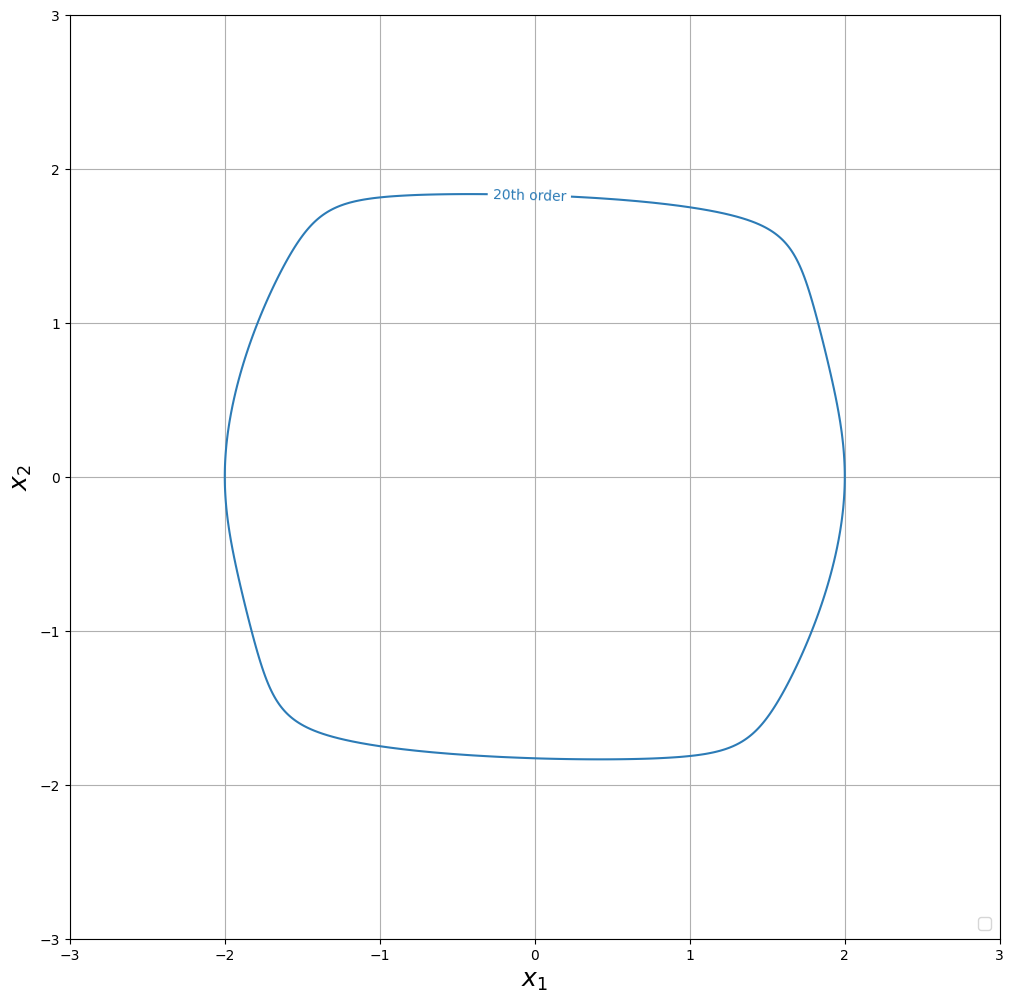

In [74]:
import sys, os
sys.path.append(os.path.abspath(".."))

from homogeneous_higher_order_lyapunov_functions import plot_reachable_set_from_hierarchical_lyap_func
plot_reachable_set_from_hierarchical_lyap_func(A_list=A_list_rtvdp, x0=jnp.array([2, 0]), c_values=[10])

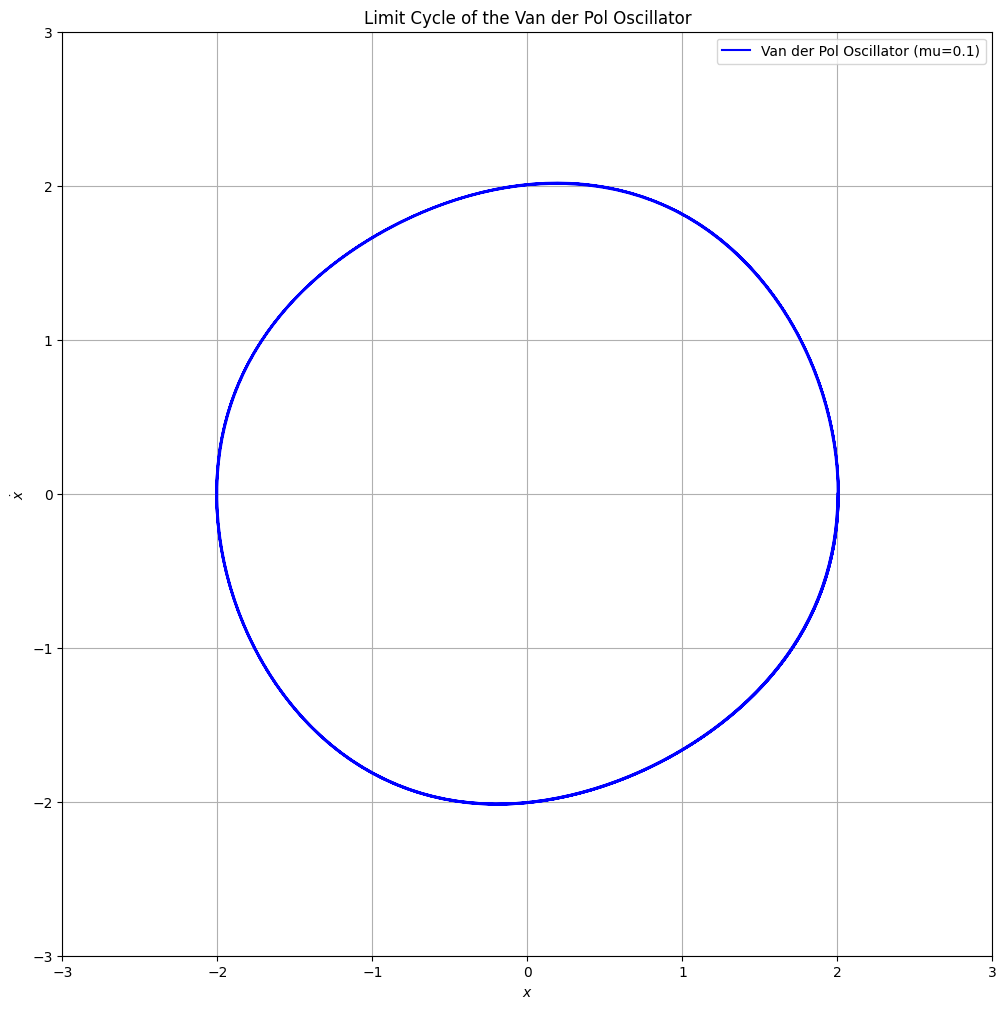

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the Van der Pol oscillator dynamics
def van_der_pol(t, y, mu=1):
    x, dx = y
    ddx = mu * (1 - x**2) * dx - x
    return [dx, ddx]

# Simulation parameters
mu = .1               # Nonlinearity parameter
y0 = [2.0, 0.0]        # Initial condition
t_span = (0, 40)       # Time range for simulation
t_eval = np.linspace(t_span[0], t_span[1], 1000)  # Time points to evaluate

# Solve the system
sol = solve_ivp(van_der_pol, t_span, y0, args=(mu,), t_eval=t_eval)

# Plot the limit cycle
plt.figure(figsize=(12, 12))
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.plot(sol.y[0], sol.y[1], label=f"Van der Pol Oscillator (mu={mu})", color='blue')
plt.xlabel('$x$')
plt.ylabel('$\dot{x}$')
plt.title('Limit Cycle of the Van der Pol Oscillator')
plt.grid()
plt.legend()
plt.show()


/home/user/anaconda3/envs/immrax/lib/python3.11/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/user/anaconda3/envs/immrax/lib/python3.11/site-packages/cvxpy/problems/problem.py:1407: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(
/home/user/output_feedback/nhholyap/homogeneous_higher_order_lyapunov_functions.py:112: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', fontsize=12)


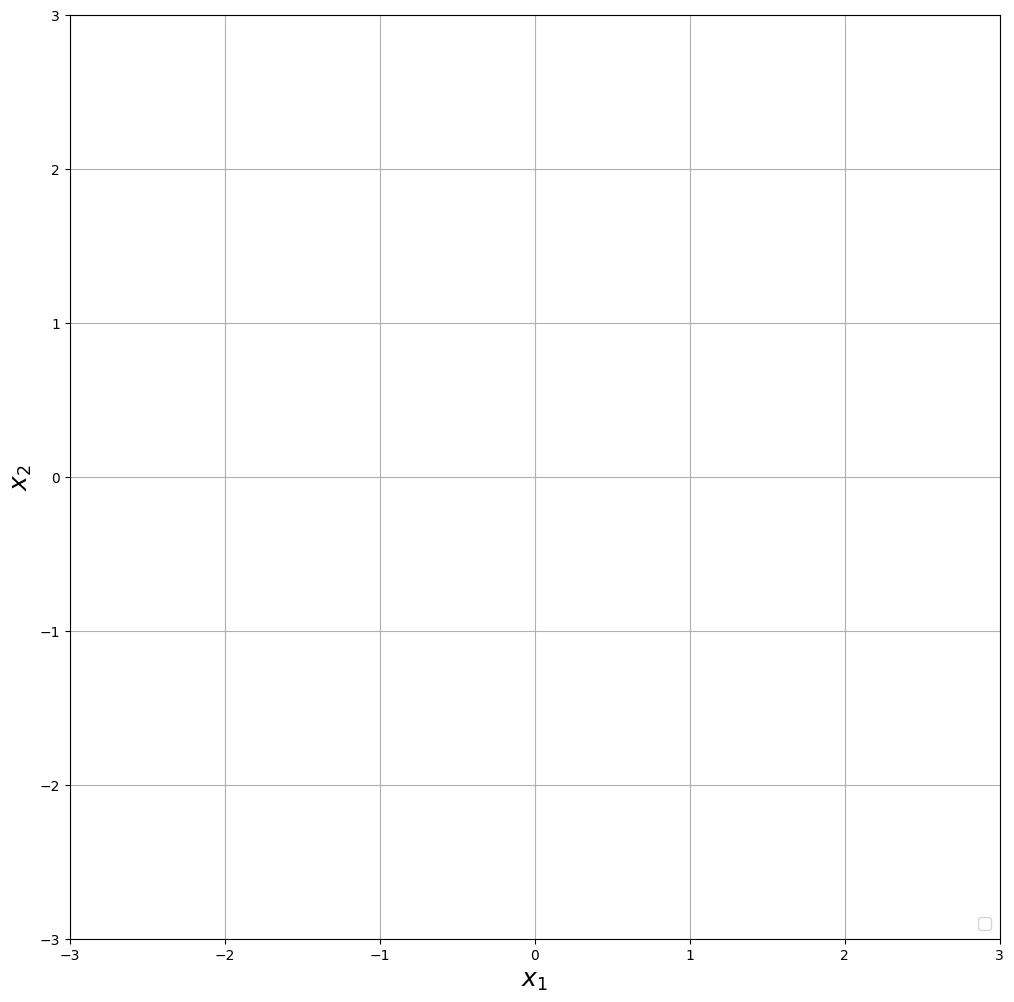

In [ ]:
from homogeneous_higher_order_lyapunov_functions import (
    calculate_lyapunov_P_matrix,
    plot_multiple_contours_2d
)
calculate_lyapunov_P_matrix(10, A_list=A_list_rtvdp)
d_plot = plot_multiple_contours_2d(c_values=[1,5,8,10], x0=jnp.zeros(2), A_list=A_list_rtvdp)

(2, 2)
(2, 2)
P_value for 1th order is: 
[[ 2.7295598  -1.93715806]
 [-1.93715806  3.16967424]]
(32, 32)
(32, 6)
P_value for 5th order is: 
[[   3.02739253  -13.03607717   26.05541911  -25.84199818   13.46199678
    -2.87716519]
 [ -13.03607717   86.5507801  -164.25307346  152.83735833  -78.41542076
    17.67572802]
 [  26.05541911 -164.25307346  428.36898853 -462.2781356   239.15278229
   -52.14725223]
 [ -25.84199818  152.83735833 -462.2781356   600.35129843 -357.82274788
    84.36465949]
 [  13.46199678  -78.41542076  239.15278229 -357.82274788  254.67065107
   -69.5263492 ]
 [  -2.87716519   17.67572802  -52.14725223   84.36465949  -69.5263492
    23.07561239]]
(256, 256)
(256, 9)
P_value for 8th order is: 
[[ 3.62514894e+00 -2.64657810e+01  8.62351653e+01 -1.64063939e+02
   2.01165436e+02 -1.62517781e+02  8.35321440e+01 -2.42930644e+01
   2.98963031e+00]
 [-2.64657810e+01  2.75564103e+02 -8.32611580e+02  1.42348168e+03
  -1.77096394e+03  1.59982182e+03 -9.08613461e+02  2.76682689e

/home/user/output_feedback/nhholyap/homogeneous_higher_order_lyapunov_functions.py:271: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right', fontsize=12)


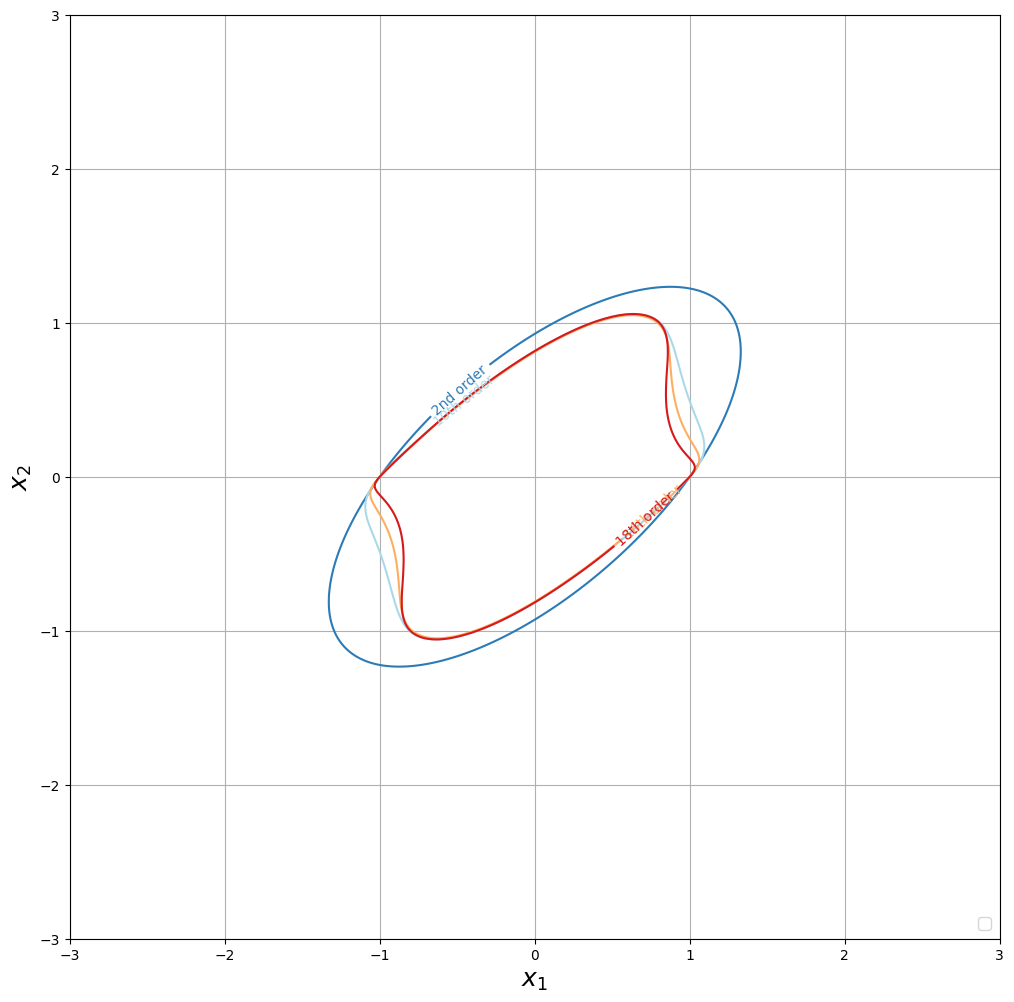

In [ ]:
# Define system matrices for switched modes
A1 = jnp.array([[-0.5, 0.5], [-0.5, -0.5]])
A2 = jnp.array([[-2.5, 2.5], [-2.5, 1.5]])
x0_abate = jnp.array([1, 0])  # Initial condition
A_list_abate = [A1, A2]
plot_reachable_set_from_hierarchical_lyap_func(A_list=A_list_abate, x0=x0_abate, )